In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    break

/kaggle/input


In [3]:
!ls /kaggle/input

dataset


In [4]:
!ls /kaggle/input/dataset

dataset


In [6]:
!ls /kaggle/input/dataset/dataset

data.yaml  images  labels


In [7]:
!cp -r /kaggle/input/dataset/dataset /kaggle/working/

In [8]:
!ls /kaggle/working

dataset


In [9]:
!ls /kaggle/working/dataset

data.yaml  images  labels


In [10]:
!ls /kaggle/working/dataset/images

train  val


In [11]:
import os

base_input = "/kaggle/working/dataset"
base_output = "/kaggle/working/enhanced_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(base_output, folder), exist_ok=True)

print("Enhanced folder structure created.")

Enhanced folder structure created.


In [12]:
import shutil

shutil.copytree(f"{base_input}/labels/train", f"{base_output}/labels/train", dirs_exist_ok=True)
shutil.copytree(f"{base_input}/labels/val", f"{base_output}/labels/val", dirs_exist_ok=True)

print("Labels copied.")

Labels copied.


In [13]:
!ls /kaggle/working

dataset  enhanced_dataset


In [14]:
!git clone https://github.com/Li-Chongyi/Zero-DCE_extension.git
%cd Zero-DCE_extension
!pip install -r requirements.txt

Cloning into 'Zero-DCE_extension'...
remote: Enumerating objects: 2140, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 2140 (delta 0), reused 2 (delta 0), pack-reused 2136 (from 1)
Receiving objects: 100% (2140/2140), 100.92 MiB | 52.94 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/kaggle/working/Zero-DCE_extension
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [15]:
%cd /kaggle/working/Zero-DCE_extension
!ls

/kaggle/working/Zero-DCE_extension
README.md  Zero-DCE++


In [16]:
%cd /kaggle/working/Zero-DCE_extension/Zero-DCE++
!ls

/kaggle/working/Zero-DCE_extension/Zero-DCE++
data	       lowlight_test.py   model.py   __pycache__
dataloader.py  lowlight_train.py  Myloss.py  snapshots_Zero_DCE++


In [18]:
import torch
from model import enhance_net_nopool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = enhance_net_nopool(scale_factor=12).to(device)

model.load_state_dict(
    torch.load("snapshots_Zero_DCE++/Epoch99.pth", map_location=device)
)

model.eval()

print("Zero-DCE++ model loaded successfully.")

Zero-DCE++ model loaded successfully.


In [19]:
%cd /kaggle/working

/kaggle/working


In [25]:
import cv2
import numpy as np
import os
from glob import glob
import torch

base_input = "/kaggle/working/dataset"
base_output = "/kaggle/working/enhanced_dataset"

def enhance_image(img_path, save_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    # Make height and width divisible by 12
    new_h = h - (h % 12)
    new_w = w - (w % 12)

    img = cv2.resize(img, (new_w, new_h))

    img = img / 255.0
    img = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        enhanced_img, _ = model(img)

    enhanced_img = enhanced_img.squeeze().permute(1,2,0).cpu().numpy()
    enhanced_img = (enhanced_img * 255).astype(np.uint8)
    enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2BGR)

    cv2.imwrite(save_path, enhanced_img)

In [26]:
train_images = glob("/kaggle/working/dataset/images/train/*")

print("Total train images:", len(train_images))

for img_path in train_images:
    filename = os.path.basename(img_path)
    save_path = f"/kaggle/working/enhanced_dataset/images/train/{filename}"
    enhance_image(img_path, save_path)

print("Training enhancement complete.")

Total train images: 8275
Training enhancement complete.


In [27]:
!ls /kaggle/working/enhanced_dataset/images/train | head

AmurLeopard_106.jpg
AmurLeopard_107.jpg
AmurLeopard_117.jpg
AmurLeopard_1186.jpg
AmurLeopard_1187.jpg
AmurLeopard_1188.jpg
AmurLeopard_1190.jpg
AmurLeopard_1191.jpg
AmurLeopard_1193.jpg
AmurLeopard_1194.jpg
ls: write error: Broken pipe


In [28]:
val_images = glob("/kaggle/working/dataset/images/val/*")

print("Total val images:", len(val_images))

for img_path in val_images:
    filename = os.path.basename(img_path)
    save_path = f"/kaggle/working/enhanced_dataset/images/val/{filename}"
    enhance_image(img_path, save_path)

print("Validation enhancement complete.")

Total val images: 2069
Validation enhancement complete.


In [29]:
!ls /kaggle/working/enhanced_dataset/images/val | head

AmurLeopard_1189.jpg
AmurLeopard_1192.jpg
AmurLeopard_1201.jpg
AmurLeopard_1208.jpg
AmurLeopard_1210.jpg
AmurLeopard_1218.jpg
AmurLeopard_1225.jpg
AmurLeopard_1226.jpg
AmurLeopard_1229.jpg
AmurLeopard_1236.jpg
ls: write error: Broken pipe


In [33]:
!ls /kaggle/working/enhanced_dataset

train  val


In [34]:
!ls /kaggle/working

dataset  enhanced_dataset  Zero-DCE_extension


In [35]:
yaml_content = """
path: /kaggle/working/enhanced_dataset

train: images/train
val: images/val

names:
  0: amurtiger
  1: badger
  2: blackbear
  3: cow
  4: dog
  5: hare
  6: leopard
  7: leopardcat
  8: muskdeer
  9: racoondog
  10: redfox
  11: roedeer
  12: sable
  13: sikadeer
  14: weasel
  15: wildboar
  16: ytmarten
"""

with open("/kaggle/working/enhanced_data.yaml", "w") as f:
    f.write(yaml_content)

print("Enhanced YAML created.")

Enhanced YAML created.


In [36]:
!ls /kaggle/working

dataset  enhanced_dataset  enhanced_data.yaml  Zero-DCE_extension


In [37]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00a 0:00:01


In [38]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")   # balanced model

model.train(
    data="/kaggle/working/enhanced_data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    optimizer="AdamW",
    lr0=0.001
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/enhanced_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c3e5f617560>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.04

In [39]:
!ls /kaggle/working/runs/detect/train

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch46620.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch46621.jpg  weights
labels.jpg			 train_batch46622.jpg


In [42]:
import pandas as pd

df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")
print(df.tail(1))

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
99    100  29413.6         0.35556         0.17311         0.85255   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
99                0.9631              0.958           0.97113   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0  \
99              0.86486       0.54794        0.2509       0.93722  0.00002   

     lr/pg1   lr/pg2  
99  0.00002  0.00002  


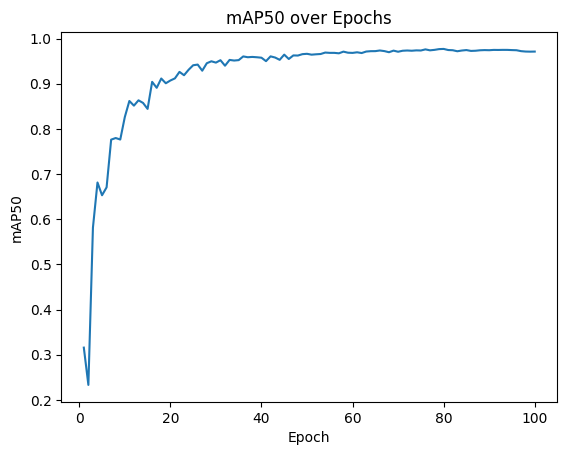

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")

plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.title("mAP50 over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.show()

In [47]:
!ls /kaggle/working/runs/detect/train/weights

best.pt  last.pt


In [48]:
import shutil

shutil.copy(
    "/kaggle/working/runs/detect/train/weights/best.pt",
    "/kaggle/working/best.pt"
)

'/kaggle/working/best.pt'

In [49]:
!ls /kaggle/working

best.pt  enhanced_dataset    runs	 yolov8m.pt
dataset  enhanced_data.yaml  yolo26n.pt  Zero-DCE_extension


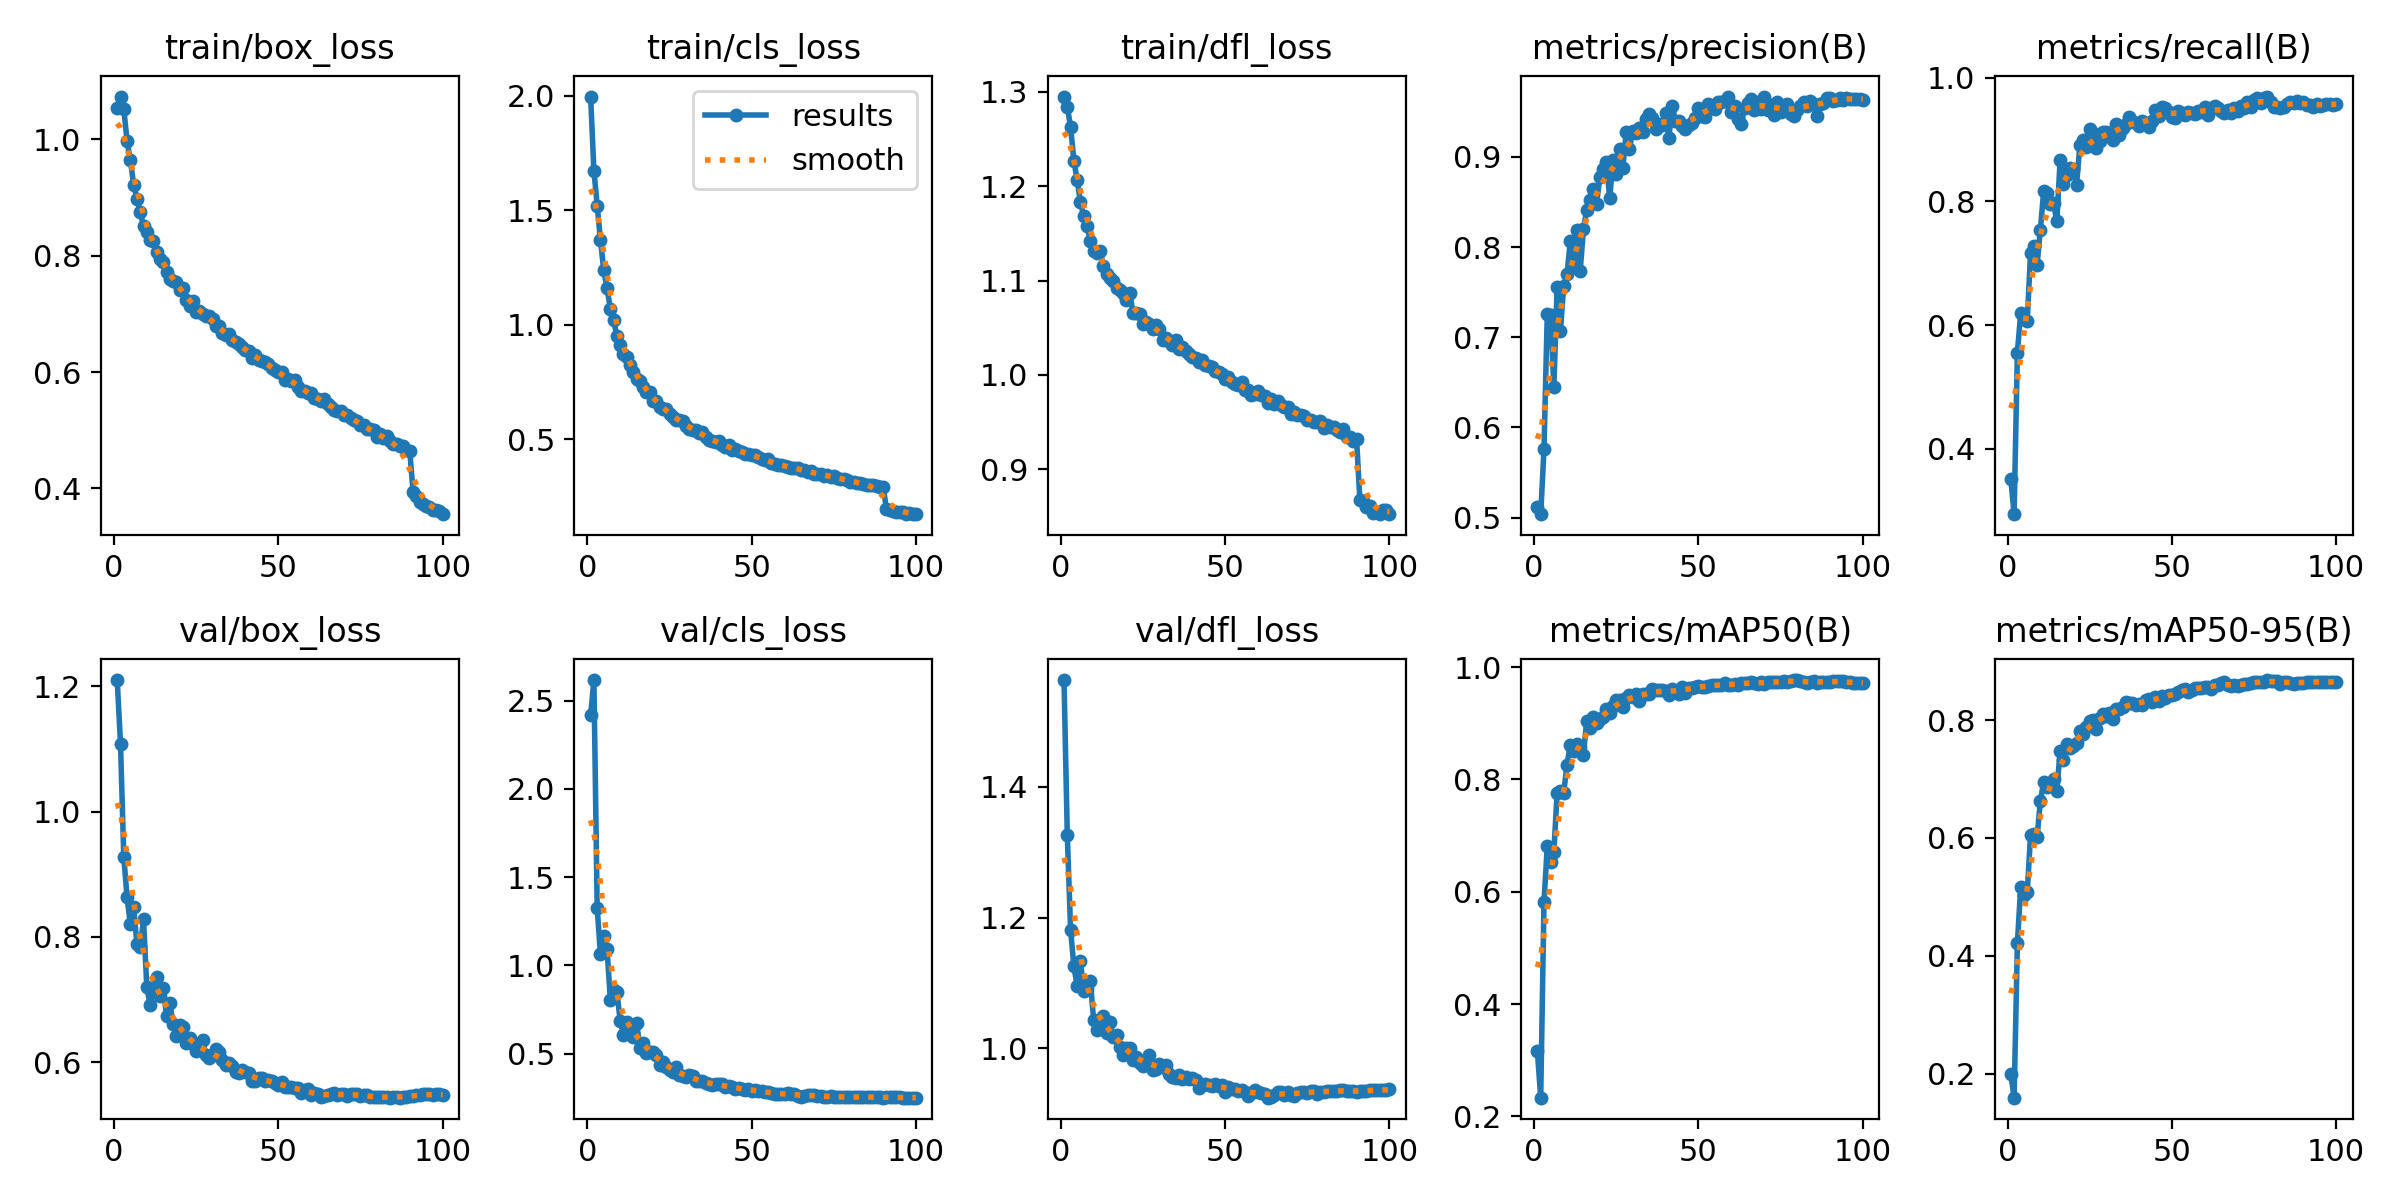

In [52]:
from IPython.display import Image
Image("/kaggle/working/runs/detect/train/results.png")

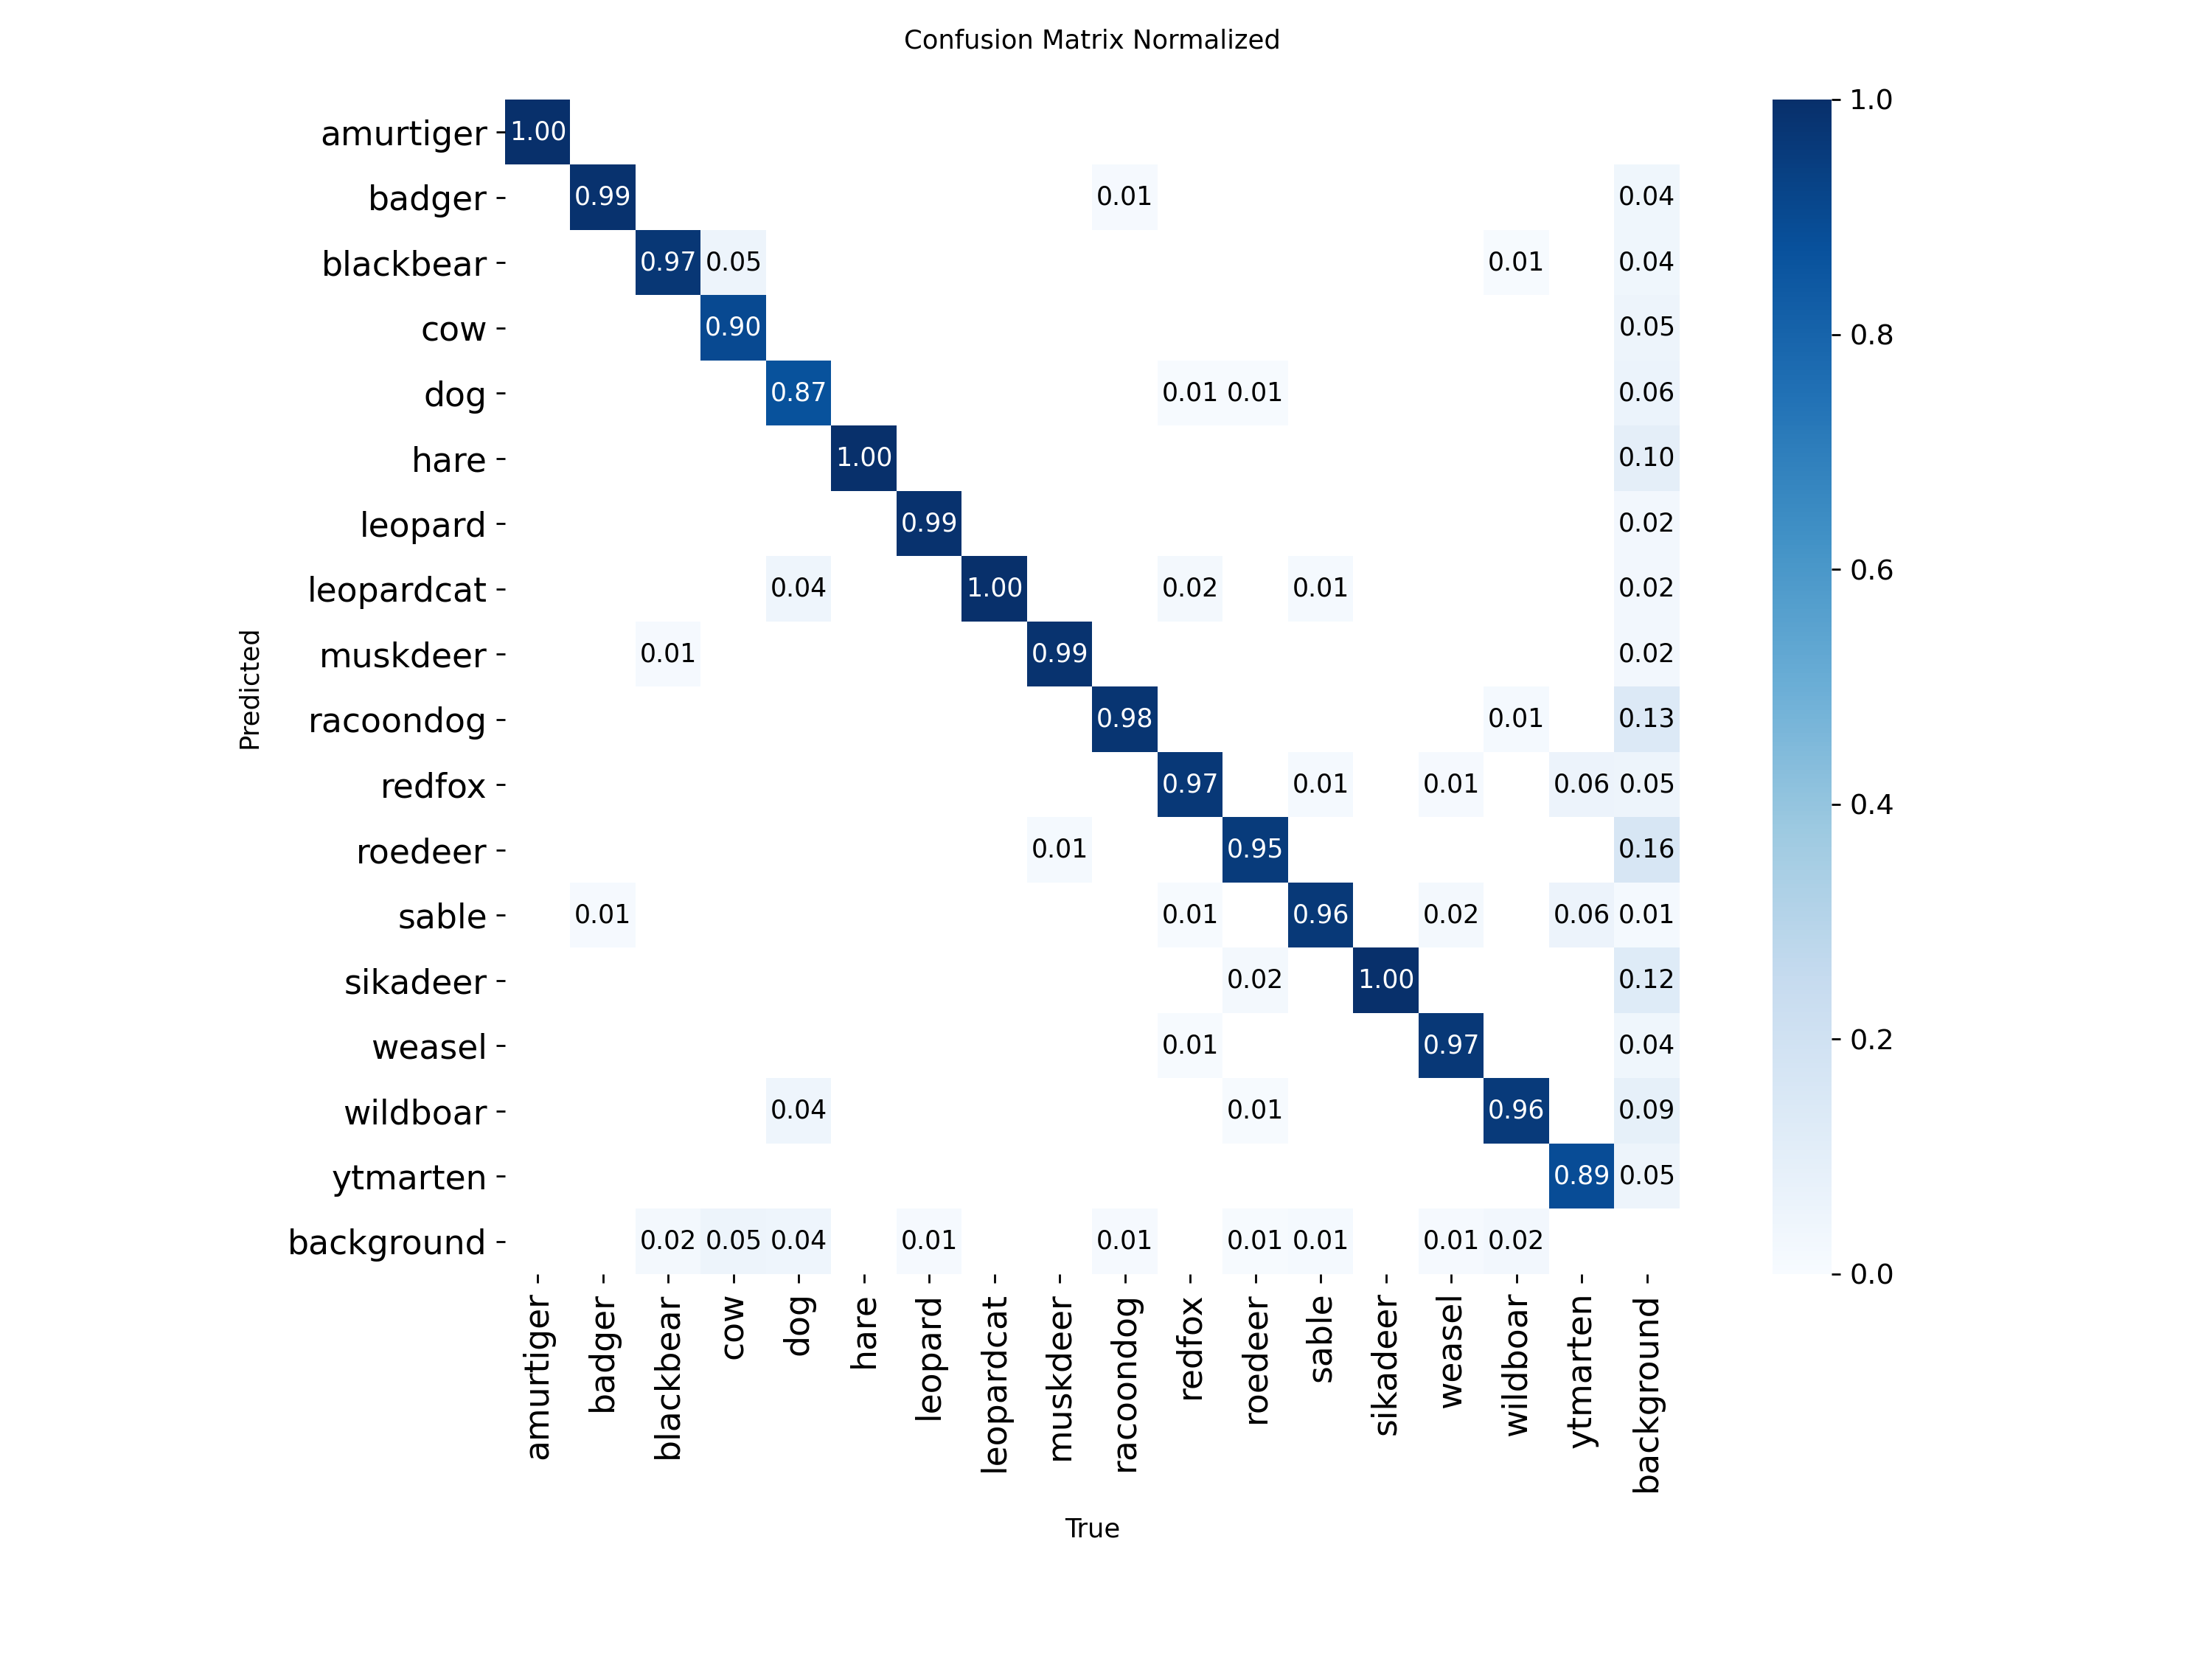

In [53]:
Image("/kaggle/working/runs/detect/train/confusion_matrix_normalized.png")

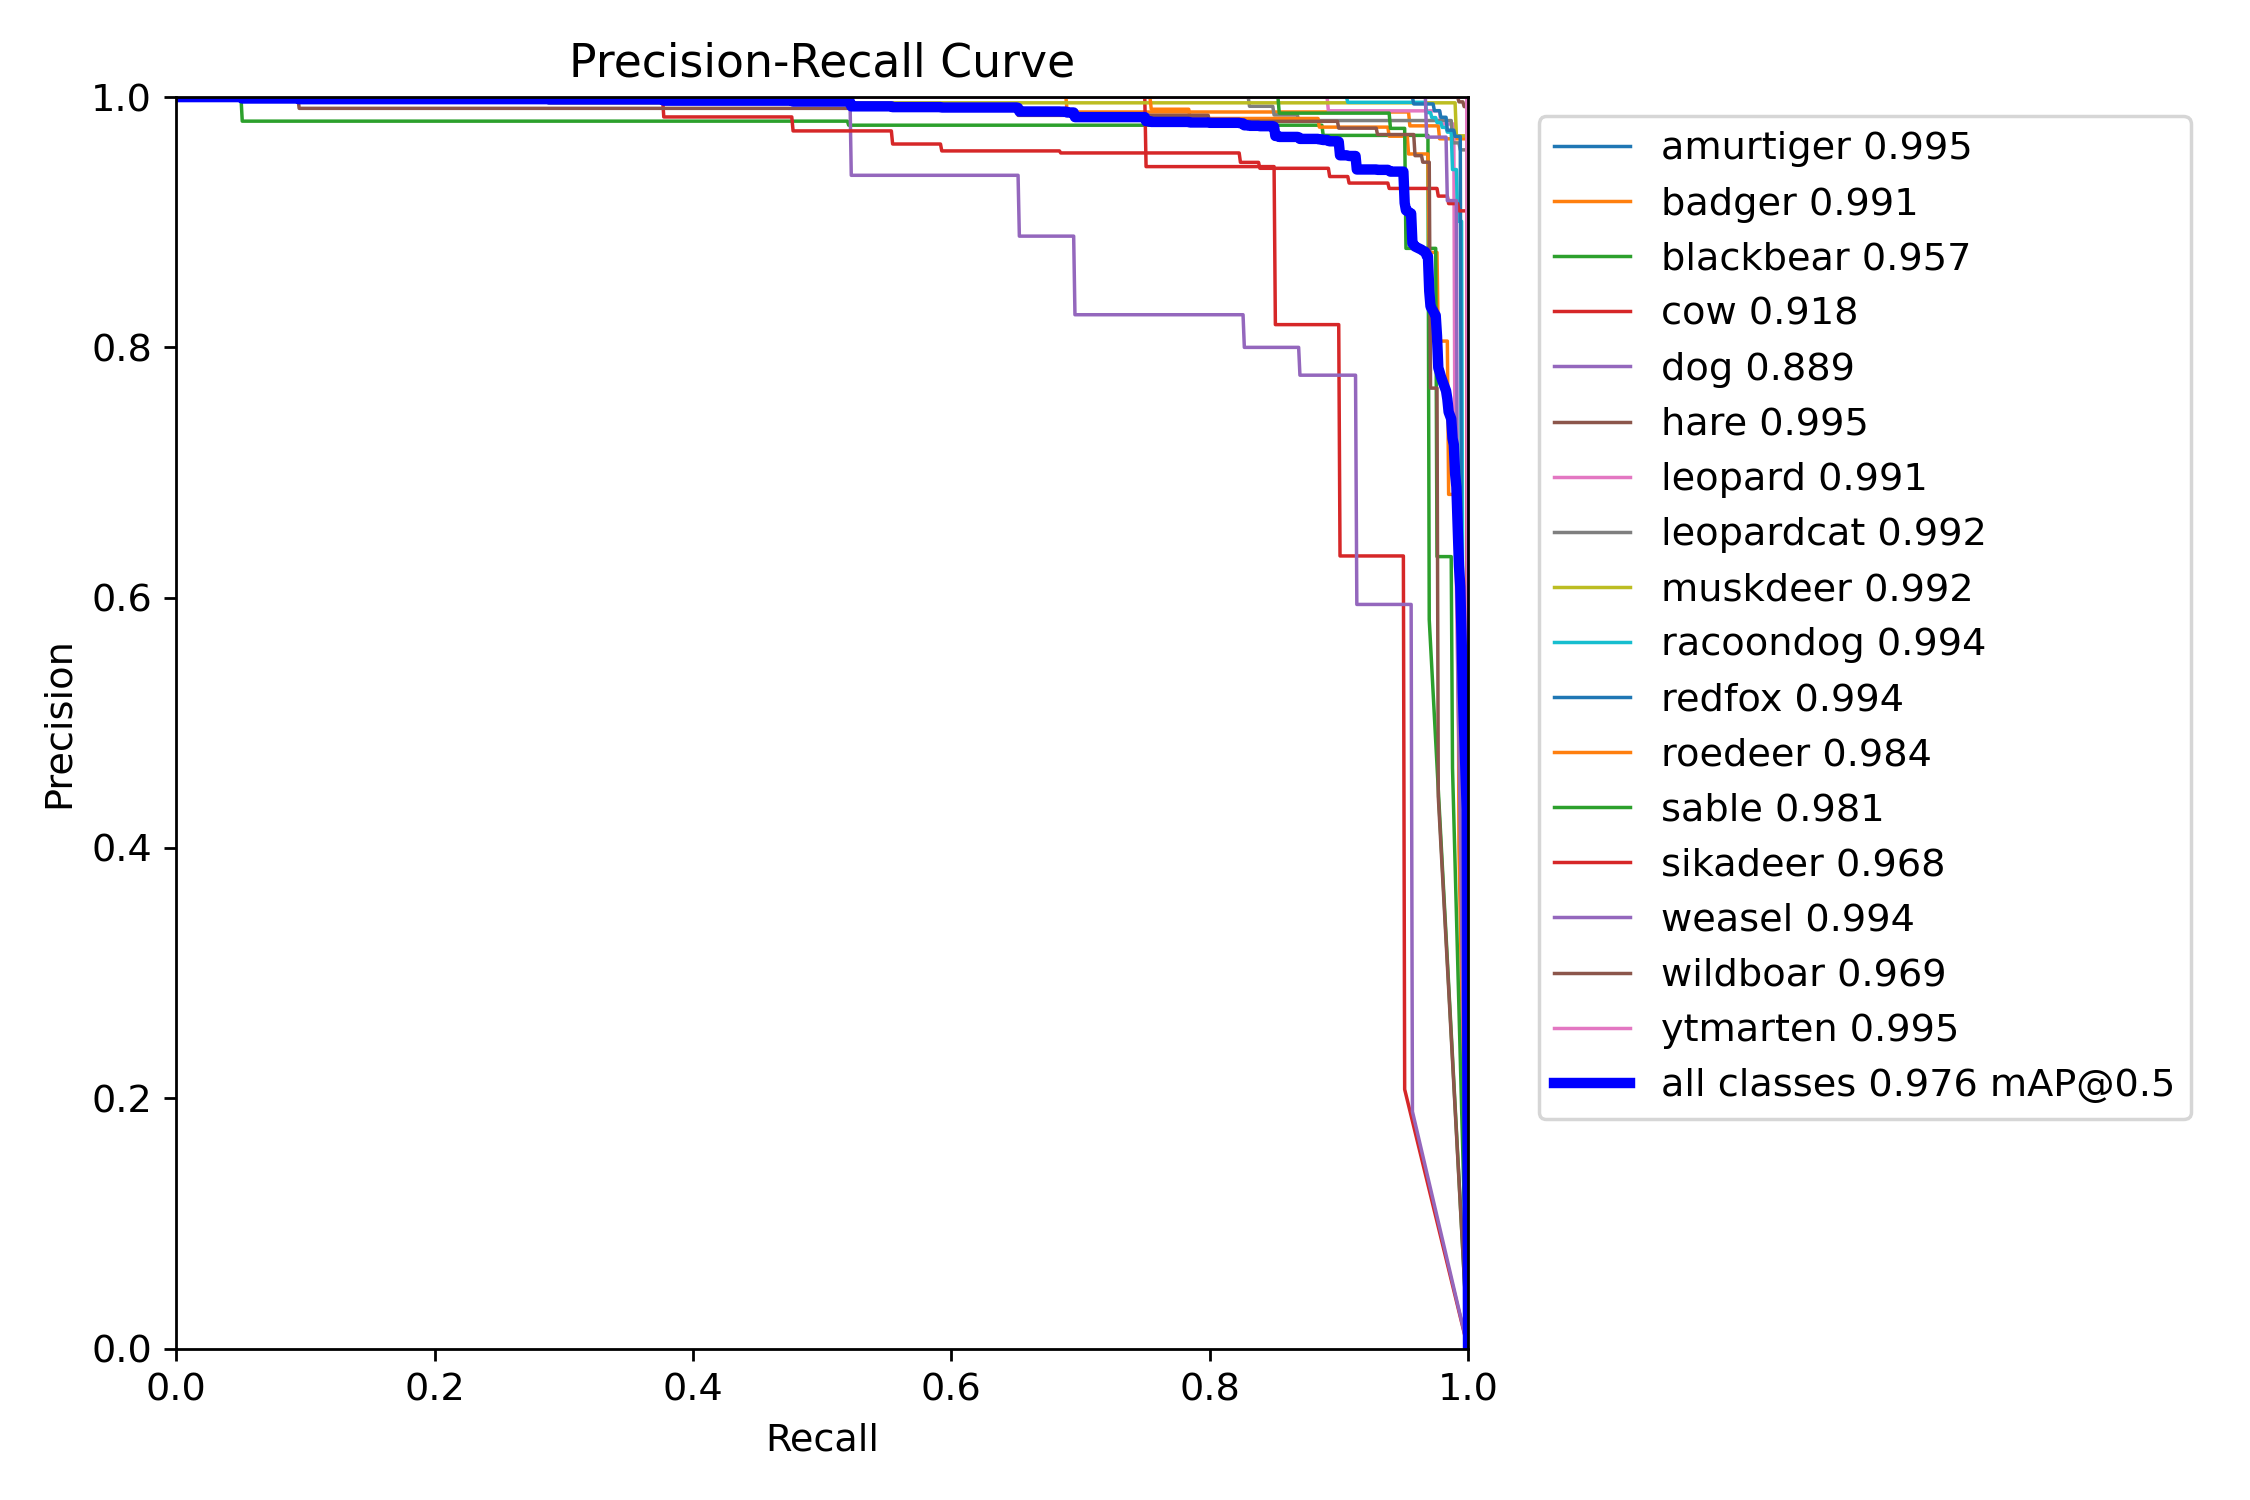

In [54]:
Image("/kaggle/working/runs/detect/train/BoxPR_curve.png")

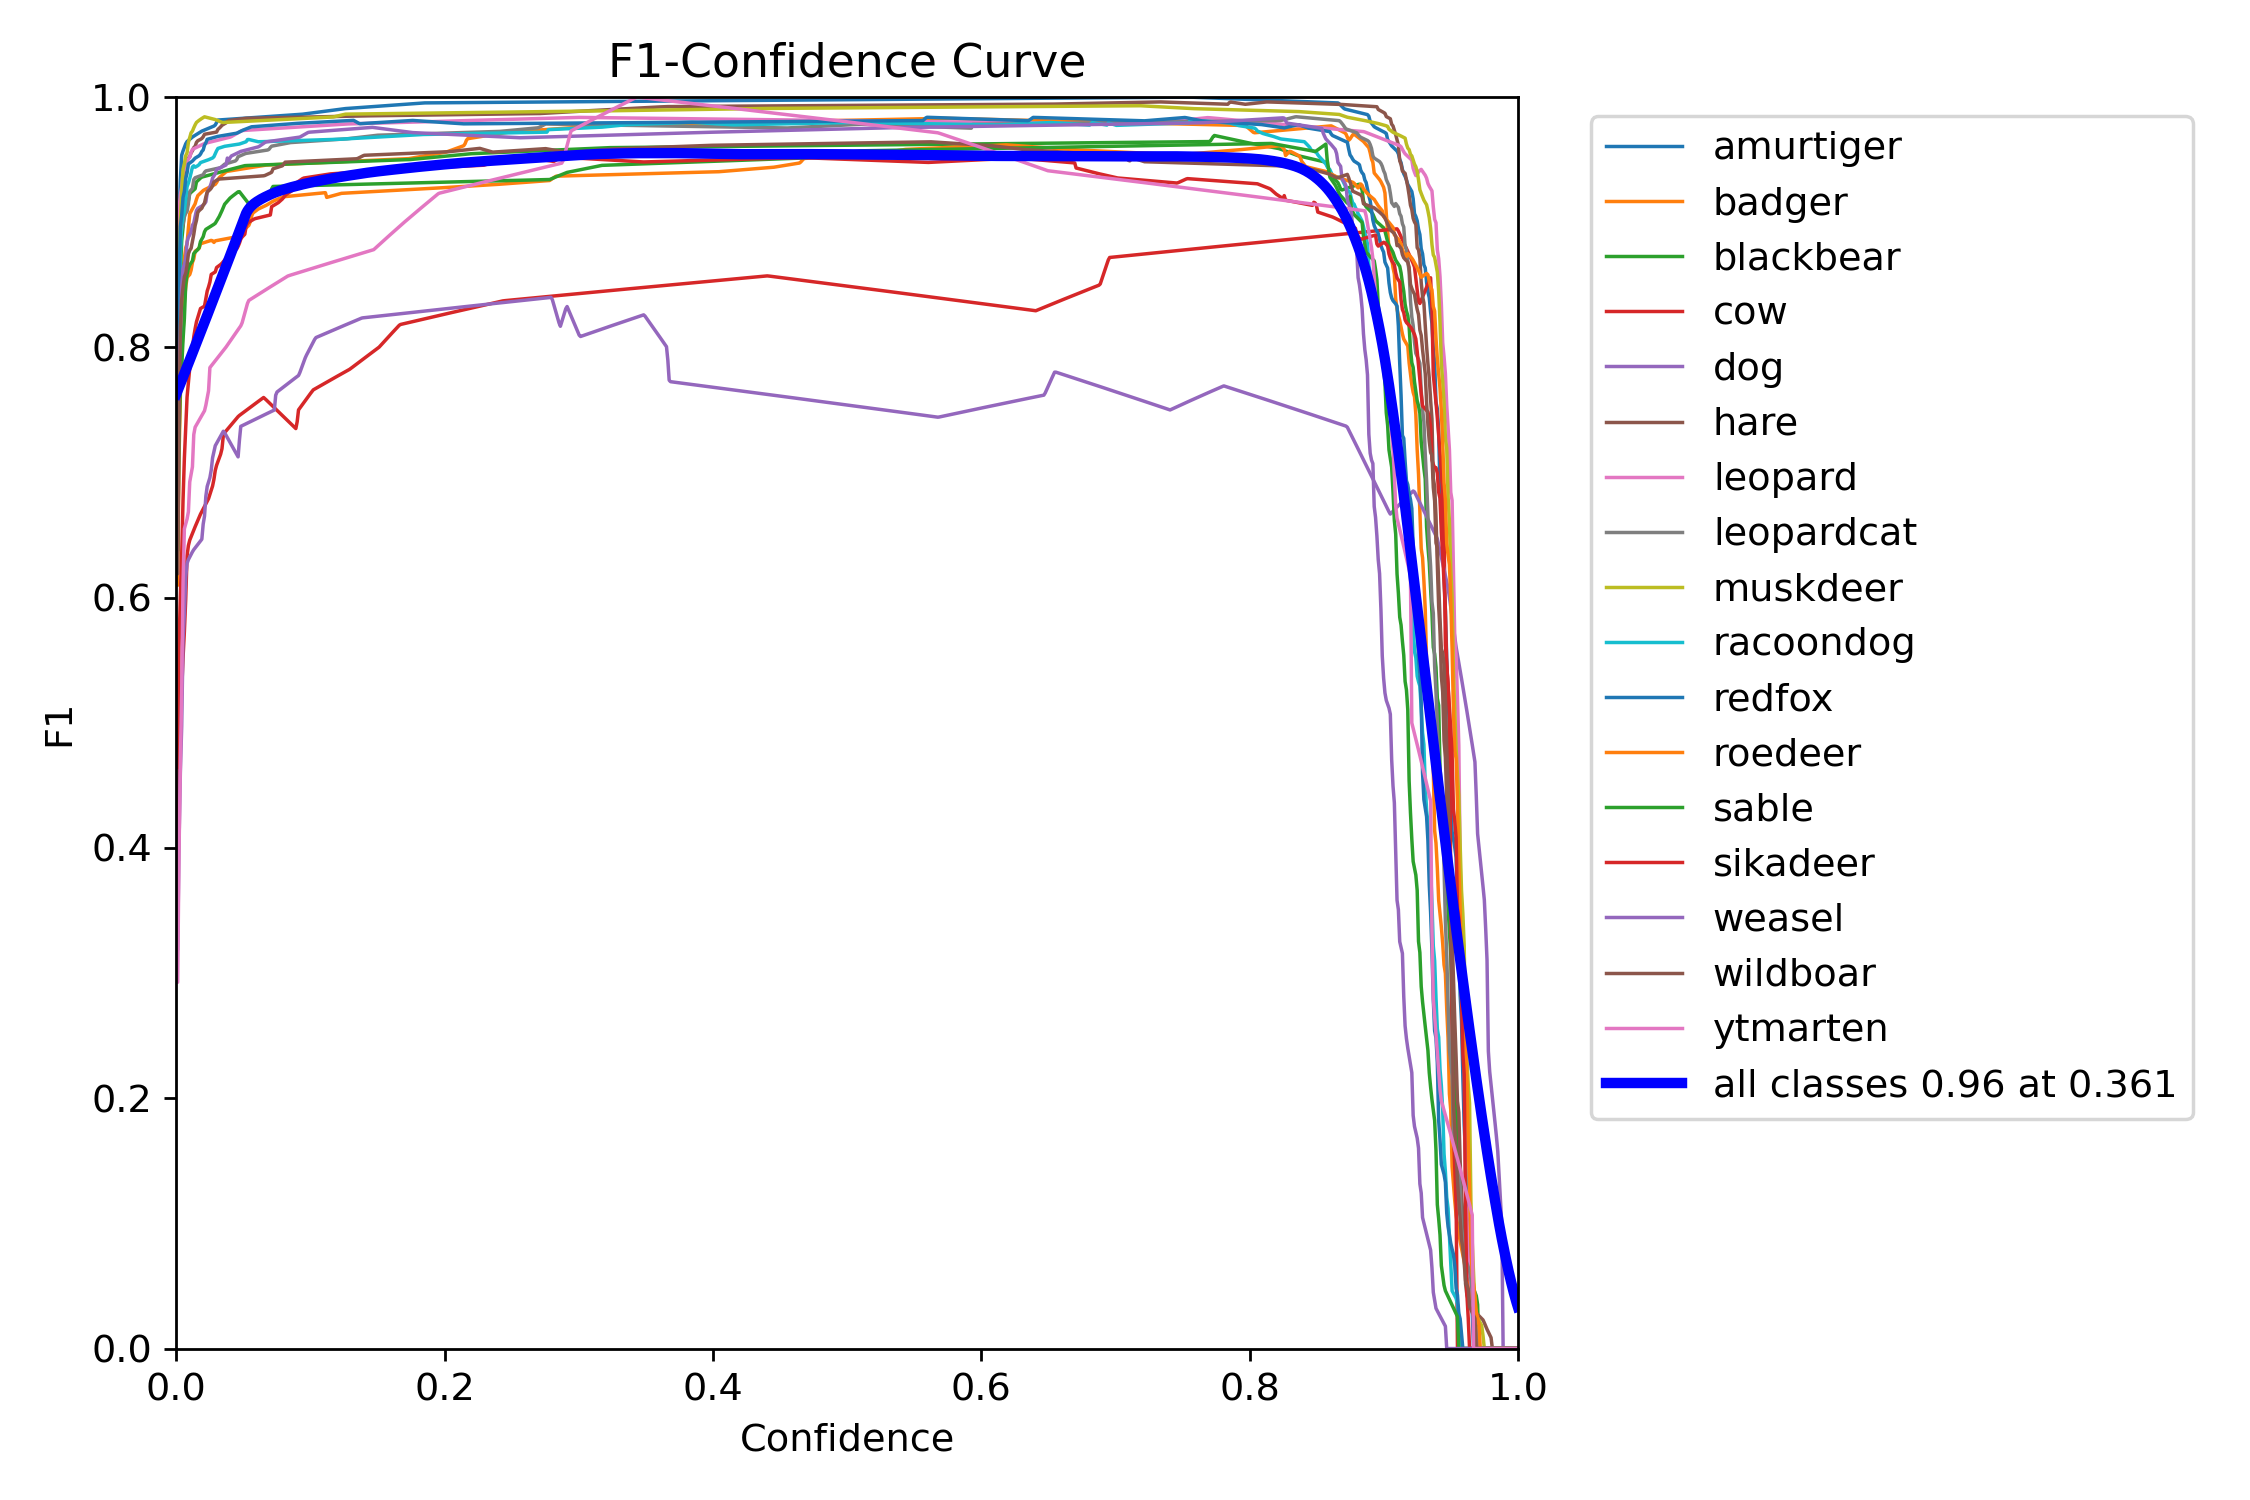

In [55]:
Image("/kaggle/working/runs/detect/train/BoxF1_curve.png")

In [56]:
import pandas as pd

df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")
df.tail(1)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
99,100,29413.6,0.35556,0.17311,0.85255,0.9631,0.958,0.97113,0.86486,0.54794,0.2509,0.93722,0.00002,0.00002,0.00002
